In [1]:
# reading tsv.gz file to dataframe 

import pandas as pd
import gzip
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

PATH_TRAIN = '/media/alvarinho/dados/Estudos/traducao-rede-neural/data/en-pt_BR.txt'

In [2]:
from itertools import islice

n = 20_000_000  # number of lines to read
qtde_pego = 0

pairs = []

progress = tqdm(total=n, desc="Reading lines", unit="line")
with open(f"{PATH_TRAIN}/OpenSubtitles.en-pt_BR.en", encoding="utf-8") as f_en, \
     open(f"{PATH_TRAIN}/OpenSubtitles.en-pt_BR.pt_BR", encoding="utf-8") as f_pt:

    for en, pt in zip(f_en, f_pt):
        if en.strip() and len(en.strip()) > 20:
            pairs.append((en.strip(), pt.strip()))
            qtde_pego += 1
            progress.update(1)
        if qtde_pego >= n:
            break

Reading lines: 100%|█████████▉| 19906867/20000000 [00:18<00:00, 1128566.75line/s]

In [3]:
# exemplo
for en, pt in pairs[:5]:
    print("EN:", en.strip())
    print("PT:", pt.strip())
    print()

EN: Director Mueller just assigned us a major case number. Investigation''s  officially been dubbed Amerithrax. Whoever sent these  letters got their Anthrax from an American lab.
PT: o diretor mueller acaba de nomear nos um número de caso principal, investigações foi oficialmente dublado amerithrax, quemosenviou cartas receberam antraz de um laboratório americano, nós não estaríamos aqui se nós não tinha provas nos conduzindo de volta para usamriid,

EN: Bruce Ivins is our top anthrax man. Then I wanna talk to him. They''re treating us like we''re the enemy.
PT: bruce ivins é o nosso melhor homem com antraz, então eu quero falar com ele, eles estão nos tratando como se fôssemos o inimigo, nós somos os heróis, a entrada tem que ser através do complexo de seu herói,

EN: I know most Americans aren''t paying attention, but you guys had signs that 9/11 was gonna happen. And now you can''t figure  out who sent these letters. So instead you are harassing hard working patriots like me.
PT: e

Reading lines: 100%|██████████| 20000000/20000000 [00:30<00:00, 1128566.75line/s]

In [4]:
df = pd.DataFrame(pairs, columns=["en", "pt"])

In [5]:
df = df.loc[
    (df['en'].str.len() > 20)
]

In [6]:
df = df.drop_duplicates(subset='en')

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 18491367 entries, 0 to 19999999
Data columns (total 2 columns):
 #   Column  Dtype
---  ------  -----
 0   en      str  
 1   pt      str  
dtypes: str(2)
memory usage: 2.0 GB


In [8]:
df.head(10)

,en,pt
0,Director Mueller just assigned us a major case...,o diretor mueller acaba de nomear nos um númer...
1,Bruce Ivins is our top anthrax man. Then I wan...,"bruce ivins é o nosso melhor homem com antraz,..."
2,I know most Americans aren''t paying attention...,eu conheço a maioria dos americanos não estão ...
3,"Bruce, are you considering doing bodily harm ...","bruce,vocêé considerando fazer fisicamente mal..."
4,"Did you this, Dr. Ivins?","você fez isso, dr, ivins?"
5,I had obsessive behaviors linked to sororitie...,tiveobsessivo comportamentos ligados a irmanda...
6,- No. - Looks like he''s not your guy. Our top...,"- não, - parece que ele está não seu cara, nos..."
7,FBI agents searched the home of Steven Hatfil...,:fbi agentes vasculharam a casa de steven hat...
8,"Hello, mother. Hello, Bruce.","- olá mãe, - olá, bruce,"
9,"Hello, papa. What are you doing?","olá, papai, o que você está fazendo?"


In [9]:
examples = df.sample(10)

for _, row in examples.iterrows():
    print("EN:", row['en'])
    print("PT:", row['pt'])
    print()

EN: I'm confident my men will capture the target.
PT: Estou confiante que meus homens irão capturar o alvo.

EN: Oh, hey, one more thing.
PT: Outra coisa...

EN: Woke him up and made him cook.
PT: Acordei-o e o fiz cozinhar.

EN: This airplane ticket for Asian Flight 107 was found in Detective Sha's pocket.
PT: Esta passagem de avião para o voo asiático 107 foi encontrada no bolso do detetive Sha.

EN: - Which one's your favourite?
PT: Qual é a sua favorita?

EN: Master, looking for me?
PT: Mestre, olhando para mim?

EN: Look at this gorgeous city.
PT: Olhe para esta linda cidade.

EN: - 'An American lieutenant? ' - 'Yes.'
PT: Um marinheiro americano.

EN: - He was murdered and you know it.
PT: -Imagine... Ele foi assassinado, você sabe.

EN: Weeds can never be killed!
PT: Ervas daninhas nunca podem ser mortas!



In [10]:
df['en_length'] = df['en'].str.len()
df['pt_length'] = df['pt'].str.len()

In [11]:
df['en_length'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    1.849137e+07
mean     4.570503e+01
std      2.521567e+01
min      2.100000e+01
25%      2.900000e+01
50%      3.800000e+01
75%      5.400000e+01
90%      7.600000e+01
95%      9.400000e+01
99%      1.410000e+02
max      3.269000e+03
Name: en_length, dtype: float64

In [13]:
df = df[df['en_length'] <= df['en_length'].quantile(0.90)]

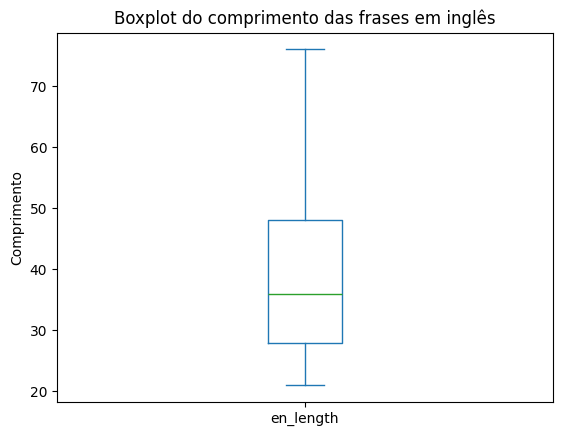

In [14]:
df['en_length'].plot.box()
plt.title("Boxplot do comprimento das frases em inglês")
plt.ylabel("Comprimento")
plt.show()

In [15]:
len(df)

16682633

In [16]:
df = df[
    (df['pt_length'] >= (df['en_length'] * 0.90)) &
    (df['pt_length'] <= (df['en_length'] * 1.1))
    ]

In [17]:
len(df)

5841520

In [18]:
df

,en,pt,en_length,pt_length
3,"Bruce, are you considering doing bodily harm ...","bruce,vocêé considerando fazer fisicamente mal...",57,56
4,"Did you this, Dr. Ivins?","você fez isso, dr, ivins?",24,25
13,"But you still don''t believe me, do you?","mas você ainda não acredita em mim, não é?",40,42
21,Did you get pulled onto Sykes'' team too?,você foi puxado na equipe de sykes também?,41,42
29,This is a mistake. I''m...,"isto é um erro, eu estou,",26,25
...,...,...,...,...
19999992,Omar. Try to forget her.,"Omar, tente esquecê-la.",24,23
19999994,"If you want, she is yours.","Se você quiser, ela é sua.",26,26
19999996,Finally we have a name.,Finalmente temos um nome.,23,25
19999997,The Byzantines are trying to press through our...,"Os bizantinos, tentaram atravessar as provínci...",65,60


In [19]:
df['en'] = df['en'].str.capitalize()
df['pt'] = df['pt'].str.capitalize()

In [20]:
df['en'] = df.apply(lambda x: x['en'][:-1] if x['en'][-1] in [','] else x['en'], axis=1)
df['pt'] = df.apply(lambda x: x['pt'][:-1] if x['pt'][-1] in [','] else x['pt'], axis=1)

In [21]:
df['en'] = df.apply(lambda x: x['en']+'.' if x['en'][-1] not in ['.', '!', '?'] else x['en'], axis=1)
df['pt'] = df.apply(lambda x: x['pt']+'.' if x['pt'][-1] not in ['.', '!', '?'] else x['pt'], axis=1)

In [22]:
df['en_max_len_word'] = df['en'].apply(lambda x: max(len(word) for word in x.split()))
df['pt_max_len_word'] = df['pt'].apply(lambda x: max(len(word) for word in x.split()))

In [23]:
df.en_max_len_word.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    5.841520e+06
mean     7.913939e+00
std      2.125473e+00
min      2.000000e+00
25%      6.000000e+00
50%      8.000000e+00
75%      9.000000e+00
90%      1.100000e+01
95%      1.200000e+01
99%      1.400000e+01
max      6.000000e+01
Name: en_max_len_word, dtype: float64

In [24]:
df.loc[df['en_max_len_word'] > 20].en.values[100]

"Theo kretschmar-schuldorff will forfeit his entrance fee if he doesn't..."

In [25]:
df = df.loc[df['en_max_len_word'] <= df['en_max_len_word'].quantile(0.9)]
df = df.loc[df['pt_max_len_word'] <= df['pt_max_len_word'].quantile(0.9)]

In [27]:
df = df.reset_index(drop=True)

In [28]:
index = int(df.sample(1).index[0])
print(df.en.values[index])
print(df.pt.values[index])

What all do you hunt?
- e o que vocês caçam?


In [29]:
train_df = df.sample(frac=0.8, random_state=42)
eval_test_df = df.drop(train_df.index)
test_df = eval_test_df.sample(frac=0.8, random_state=42)
eval_df = eval_test_df.drop(test_df.index)

In [30]:
len(train_df), len(eval_df), len(test_df)

(4086243, 204312, 817249)

In [31]:
len(eval_df)

204312

In [32]:
eval_df.head()

,en,pt,en_length,pt_length,en_max_len_word,pt_max_len_word
21,His name is on the patent. what kind of a payd...,"O nome dele está na patente, que tipo de dia d...",75,79,7,9
35,How does he know that song?,Como ele conhece essa musica?,27,29,5,7
46,"Vaccines. oh. well, a little evil for the grea...","- vacinas, - oh, bem, um pouco mal para o bem ...",60,58,9,8
69,They're an extraction team.,São uma equipe de extração.,27,27,10,9
84,"But for tom, it was business.",Mas para o tom foram negócios.,29,30,9,9


In [33]:
train_df.to_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/train.csv', index=False)
eval_df.to_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/eval.csv', index=False)
test_df.to_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/test.csv', index=False)

In [2]:
eval_df = pd.read_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/eval.csv')

In [34]:
for index in np.random.choice(len(eval_df), size=20, replace=False):
    print('Inglês:', eval_df['en'].iloc[index])
    print('Português:', eval_df['pt'].iloc[index])
    print('-'*200)

Inglês: You take care of loading.
Português: Você se ocupa da carga.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: About 20 minutes from the lt, sir.
Português: Cerca de 20 minutos do lt, senhor.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: It's all right, wally.
Português: Não tem nada, wally.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: You'll see men who aren't afraid to look death in the face with pride.
Português: Vai ver homens que não têm medo de olhar para a morte com orgulho.
-------------------